# Scheil Solidification — 316L Stainless Steel

**Repository**: matreum/am-solidification-screening | **Notebook 01**

## Purpose

Demonstrate a complete non-equilibrium solidification calculation for 316L stainless steel
using the Scheil-Gulliver model. This foundational notebook walks through every step and
produces the solidification curve that all subsequent notebooks build on.

### The Scheil-Gulliver Model

The Scheil model assumes:
- **Complete mixing** in the liquid phase (infinite diffusion)
- **Zero diffusion** in the solid phase (no back-diffusion)
- **Local equilibrium** at the solid-liquid interface

This represents the worst-case microsegregation scenario — the maximum compositional
inhomogeneity that develops during solidification. Conservative and suitable for screening.

### 316L Nominal Composition

| Element | wt% | Role |
|---------|-----|------|
| Fe | Balance | Matrix |
| Cr | 17.0 | Corrosion resistance, ferrite stabilizer |
| Ni | 12.0 | Austenite stabilizer |
| Mo | 2.5 | Pitting resistance, strengthening |
| Mn | 1.5 | Deoxidizer, austenite stabilizer |
| Si | 0.5 | Deoxidizer, fluidity |
| C | 0.02 | Interstitial strengthener (low for "L" grade) |

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

# Add src to path for local development
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

from matreum_am_screening.core import run_scheil, ALLOY_316L, kou_index, clyne_davies, rdg_index
from matreum_am_screening.plotting import (
    plot_solidification_curve, plot_phase_evolution, plot_liquid_enrichment
)

plt.rcParams['figure.dpi'] = 120
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## Thermodynamic Database

We use the `steel_database_fix.tdb` database from pycalphad-sandbox, which covers the
Fe-Cr-Ni-Mo-Mn-Si-C system with assessed interaction parameters. This database is derived
from published CALPHAD assessments and is suitable for solidification screening of austenitic
stainless steels.

**Components**: Fe, Cr, Ni, Mo, Mn, Si, C (7-component system)
**Candidate phases**: LIQUID, FCC_A1 (austenite), BCC_A2 (δ-ferrite), HCP_A3, SIGMA, M23C6, CEMENTITE

In [2]:
# Run Scheil simulation for 316L
print(f"Alloy: {ALLOY_316L.name}")
print(f"Components: {ALLOY_316L.components[:-1]}")  # exclude VA
print(f"Phases: {ALLOY_316L.phases}")
print(f"Starting temperature: {ALLOY_316L.start_temperature} K ({ALLOY_316L.start_temperature - 273.15:.0f} °C)")
print()
print("Running Scheil simulation (this may take 1-2 minutes)...")
result_316L = run_scheil(ALLOY_316L)
print(f"Done! {len(result_316L.temperatures_K)} temperature steps.")

Alloy: 316L SS
Components: ['FE', 'CR', 'NI', 'MO', 'MN', 'SI', 'C']
Phases: ['LIQUID', 'FCC_A1', 'BCC_A2', 'HCP_A3', 'SIGMA', 'M23C6', 'CEMENTITE']
Starting temperature: 1800.0 K (1527 °C)

Running Scheil simulation (this may take 1-2 minutes)...


Done! 428 temperature steps.


## Results

### Key Solidification Metrics

In [3]:
# Print key metrics
print(f"{'Metric':<40} {'Value':>10} {'Unit':>5}")
print("-" * 58)
print(f"{'Liquidus temperature':<40} {result_316L.T_liquidus_C:>10.1f} {'°C':>5}")
print(f"{'Solidus temperature (Scheil)':<40} {result_316L.T_solidus_C:>10.1f} {'°C':>5}")
print(f"{'Solidification range (Scheil)':<40} {result_316L.solidification_range_C:>10.1f} {'°C':>5}")
print(f"{'Number of temperature steps':<40} {len(result_316L.temperatures_K):>10d}")
print()

# Phases that formed
print("Phases formed during solidification:")
for phase, amounts in sorted(result_316L.phase_amounts.items()):
    final_frac = amounts[-1]
    if final_frac > 0.001:
        print(f"  {phase:<20} {final_frac:>8.4f} ({final_frac*100:.1f}%)")

Metric                                        Value  Unit
----------------------------------------------------------
Liquidus temperature                         1432.8    °C
Solidus temperature (Scheil)                 1154.3    °C
Solidification range (Scheil)                 278.5    °C
Number of temperature steps                     428

Phases formed during solidification:
  BCC_A2                 0.7442 (74.4%)
  FCC_A1                 0.2544 (25.4%)
  M23C6                  0.0010 (0.1%)


### Plot 1: Solidification Curve (T vs. Fraction Solid)

This is the primary deliverable — the Scheil solidification curve showing how temperature
evolves as the alloy transforms from fully liquid to fully solid. The solidification range
(ΔT) indicates the width of the mushy zone.

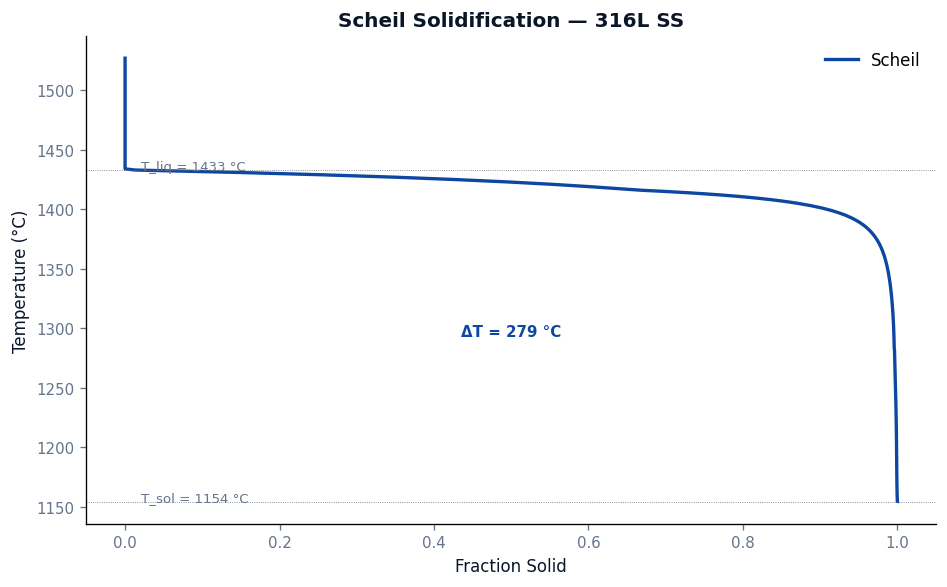

In [4]:
fig = plot_solidification_curve(result_316L)
plt.show()

### Plot 2: Phase Fraction Evolution

Shows how each phase accumulates during cooling. For 316L, the typical solidification path is:
L → L + δ(BCC) → L + δ + γ(FCC) → γ. The relative amounts of delta ferrite and austenite
depend on the Cr/Ni ratio.

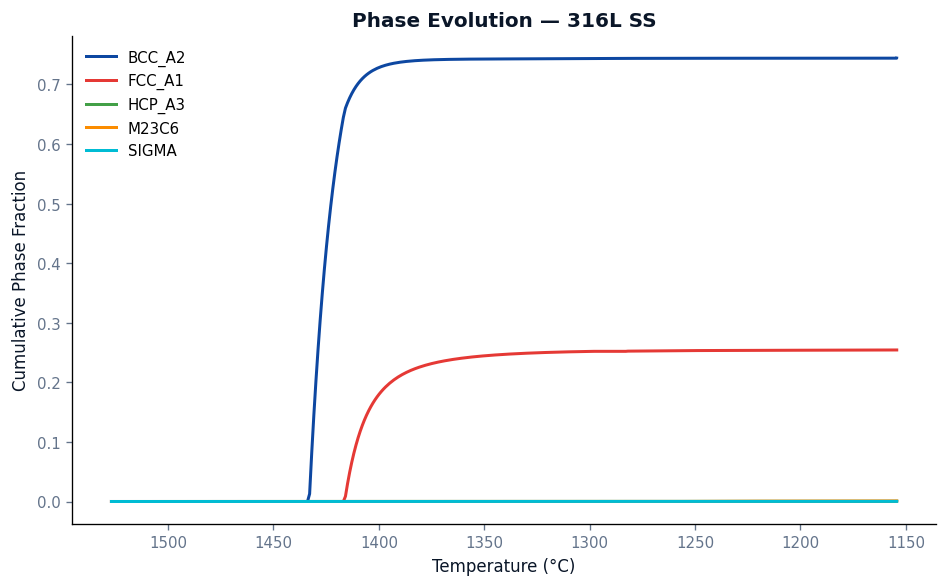

In [5]:
fig = plot_phase_evolution(result_316L)
plt.show()

### Plot 3: Liquid Composition Enrichment

As solidification proceeds, solute elements with partition coefficient k < 1 accumulate in
the remaining liquid. This enrichment drives the formation of secondary phases and controls
the terminal solidification temperature.

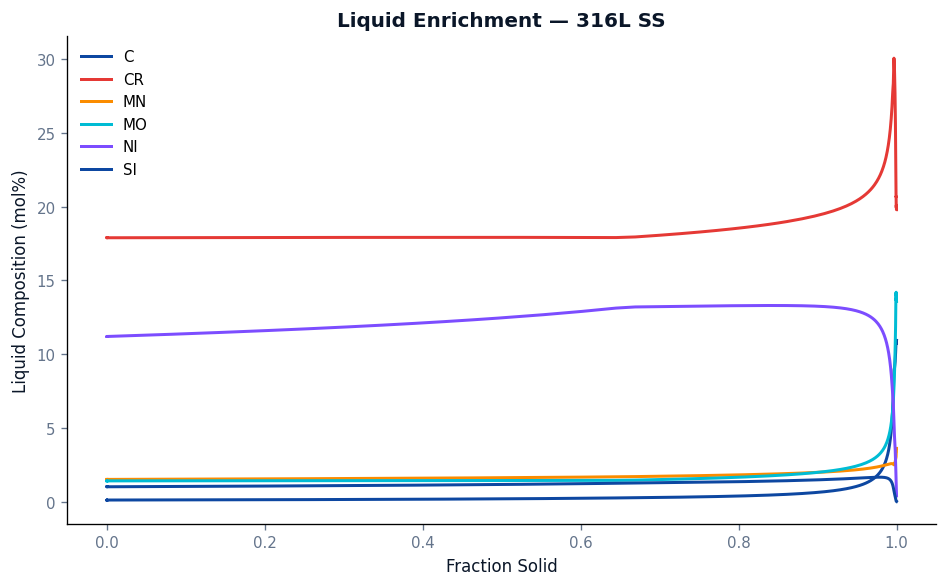

In [6]:
fig = plot_liquid_enrichment(result_316L)
plt.show()

### Hot-Cracking Susceptibility Indices

A preview of the three cracking criteria applied to 316L. These are explored in depth in Notebook 02.

In [7]:
T = result_316L.temperatures_C
fs = result_316L.fraction_solid

print(f"{'Criterion':<25} {'Value':>10} {'Interpretation'}")
print("-" * 60)
csc_kou = kou_index(T, fs)
csc_cd = clyne_davies(T, fs)
csc_rdg = rdg_index(T, fs)
print(f"{'Kou (2003)':<25} {csc_kou:>10.1f} {'°C — higher = more susceptible'}")
print(f"{'Clyne-Davies (1981)':<25} {csc_cd:>10.4f} {'ratio — higher = more susceptible'}")
print(f"{'RDG simplified':<25} {csc_rdg:>10.2f} {'a.u. — higher = more susceptible'}")

Criterion                      Value Interpretation
------------------------------------------------------------
Kou (2003)                    8403.3 °C — higher = more susceptible
Clyne-Davies (1981)           2.5176 ratio — higher = more susceptible
RDG simplified                  2.81 a.u. — higher = more susceptible


## Stated Limitations

1. **Scheil assumes zero solid-state diffusion.** Real solidification in LPBF involves rapid
   cooling but non-zero diffusion. The actual microsegregation lies between the equilibrium
   and Scheil bounds.

2. **Thermodynamic database accuracy.** Results are only as good as the assessed interaction
   parameters. The steel_database_fix.tdb is derived from published assessments but has known
   limitations for high-order interactions.

3. **No kinetic information.** Scheil gives the compositional trajectory but not the time or
   length scales. It cannot predict cooling-rate-dependent phase selection (e.g., BCC vs. FCC
   primary solidification).

4. **No thermal gradient or fluid flow effects.** Melt pool dynamics, Marangoni convection,
   and thermal gradients are not captured.

5. **Composition is nominal.** Powder lot variation, evaporation losses (Mn, Cr), and pickup
   from the atmosphere are not modeled.

---
*Matreum LLC — AM Solidification Screening, 2026*